In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Pandas options 
pd.set_option('display.max_colwidth', 1000, 'display.max_rows', None, 'display.max_columns', None)

# Plotting options
%matplotlib inline
mpl.style.use('ggplot')
sns.set(style='whitegrid')

In [2]:
loans = pd.read_csv('/kaggle/input/lending-club/accepted_2007_to_2018Q4.csv.gz', low_memory=False)

In [3]:
loans.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.action?loan_id=68407277,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,NaN,Mar-2019,564.0,560.0,0.0,30.0,1.0,Individual,NaN,NaN,NaN,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.action?loan_id=68355089,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,NaN,Mar-2019,699.0,695.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300

In [4]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB


In [5]:
loans['loan_status'].value_counts(dropna=False)

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
NaN                                                         33
Name: count, dtype: int64

In [6]:
loans = loans.loc[loans['loan_status'].isin(['Fully Paid', 'Charged Off'])]

In [7]:
loans.shape

(1345310, 151)

In [8]:
loans['loan_status'].value_counts(dropna=False)

loan_status
Fully Paid     1076751
Charged Off     268559
Name: count, dtype: int64

In [9]:
loans['loan_status'].value_counts(normalize=True, dropna=False)

loan_status
Fully Paid     0.800374
Charged Off    0.199626
Name: proportion, dtype: float64

In [10]:
missing_fractions = loans.isnull().mean().sort_values(ascending=False)
missing_fractions.head(10)

member_id                                     1.000000
next_pymnt_d                                  1.000000
orig_projected_additional_accrued_interest    0.997206
hardship_end_date                             0.995723
hardship_length                               0.995723
hardship_loan_status                          0.995723
payment_plan_start_date                       0.995723
hardship_status                               0.995723
hardship_type                                 0.995723
hardship_reason                               0.995723
dtype: float64

Text(0, 0.5, 'Feature count')

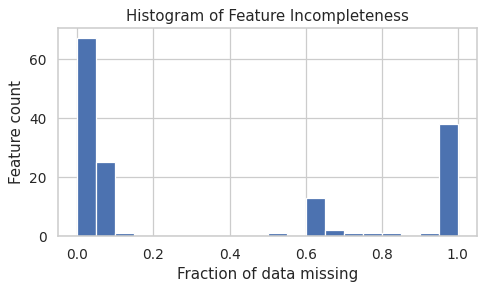

In [11]:
plt.figure(figsize=(6,3), dpi=90)
missing_fractions.plot.hist(bins=20)
plt.title('Histogram of Feature Incompleteness')
plt.xlabel('Fraction of data missing')
plt.ylabel('Feature count')

In [12]:
drop_list = sorted(list(missing_fractions[missing_fractions > 0.3].index))
print(drop_list)

['all_util', 'annual_inc_joint', 'debt_settlement_flag_date', 'deferral_term', 'desc', 'dti_joint', 'hardship_amount', 'hardship_dpd', 'hardship_end_date', 'hardship_last_payment_amount', 'hardship_length', 'hardship_loan_status', 'hardship_payoff_balance_amount', 'hardship_reason', 'hardship_start_date', 'hardship_status', 'hardship_type', 'il_util', 'inq_fi', 'inq_last_12m', 'max_bal_bc', 'member_id', 'mths_since_last_delinq', 'mths_since_last_major_derog', 'mths_since_last_record', 'mths_since_rcnt_il', 'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq', 'next_pymnt_d', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'open_rv_12m', 'open_rv_24m', 'orig_projected_additional_accrued_interest', 'payment_plan_start_date', 'revol_bal_joint', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_earliest_cr_line', 'sec_app_fico_range_high', 'sec_app_fico_range_low', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_mths_since_last_ma

In [13]:
len(drop_list)

58

In [14]:
loans.drop(labels=drop_list, axis=1, inplace=True)
loans.shape

(1345310, 93)

In [15]:
print(sorted(loans.columns))

['acc_now_delinq', 'acc_open_past_24mths', 'addr_state', 'annual_inc', 'application_type', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'collection_recovery_fee', 'collections_12_mths_ex_med', 'debt_settlement_flag', 'delinq_2yrs', 'delinq_amnt', 'disbursement_method', 'dti', 'earliest_cr_line', 'emp_length', 'emp_title', 'fico_range_high', 'fico_range_low', 'funded_amnt', 'funded_amnt_inv', 'grade', 'hardship_flag', 'home_ownership', 'id', 'initial_list_status', 'inq_last_6mths', 'installment', 'int_rate', 'issue_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'last_pymnt_amnt', 'last_pymnt_d', 'loan_amnt', 'loan_status', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sa

In [16]:
keep_list = ['addr_state', 'annual_inc', 'application_type', 'dti', 'earliest_cr_line', 'emp_length', 'emp_title', 'fico_range_high', 'fico_range_low', 'grade', 'home_ownership', 'id', 'initial_list_status', 'installment', 'int_rate', 'issue_d', 'loan_amnt', 'loan_status', 'mort_acc', 'open_acc', 'pub_rec', 'pub_rec_bankruptcies', 'purpose', 'revol_bal', 'revol_util', 'sub_grade', 'term', 'title', 'total_acc', 'verification_status', 'zip_code']

In [17]:
len(keep_list)

31

In [18]:
drop_list = [col for col in loans.columns if col not in keep_list]
print(drop_list)

['funded_amnt', 'funded_amnt_inv', 'pymnt_plan', 'url', 'delinq_2yrs', 'inq_last_6mths', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'policy_code', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc

In [19]:
len(drop_list)

62

In [20]:
loans.drop(labels=drop_list, axis=1, inplace=True)

In [21]:
loans.shape

(1345310, 31)

In [22]:
def plot_var(col_name, full_name, continuous):
    """
    Visualize a variable with and without faceting on the loan status.
    - col_name is the variable name in the dataframe
    - full_name is the full variable name
    - continuous is True if the variable is continuous, False otherwise
    """
    f, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,3), dpi=90)
    
    # Plot without loan status
    if continuous:
        sns.distplot(loans.loc[loans[col_name].notnull(), col_name], kde=False, ax=ax1)
    else:
        sns.countplot(loans[col_name], order=sorted(loans[col_name].unique()), color='#5975A4', saturation=1, ax=ax1)
    ax1.set_xlabel(full_name)
    ax1.set_ylabel('Count')
    ax1.set_title(full_name)

    # Plot with loan status
    if continuous:
        sns.boxplot(x=col_name, y='loan_status', data=loans, ax=ax2)
        ax2.set_ylabel('')
        ax2.set_title(full_name + ' by Loan Status')
    else:
        charge_off_rates = loans.groupby(col_name)['loan_status'].value_counts(normalize=True).loc[:,'Charged Off']
        sns.barplot(x=charge_off_rates.index, y=charge_off_rates.values, color='#5975A4', saturation=1, ax=ax2)
        ax2.set_ylabel('Fraction of Loans Charged-off')
        ax2.set_title('Charge-off Rate by ' + full_name)
    ax2.set_xlabel(full_name)
    
    plt.tight_layout()

In [23]:
print(list(loans.columns))

['id', 'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'application_type', 'mort_acc', 'pub_rec_bankruptcies']


In [24]:
loans['id'].sample(5)

1316390     12596222
1144334     34472831
2120531    122255393
1802934      7047821
435656     130339013
Name: id, dtype: object

In [25]:
loans['id'].describe()

count      1345310
unique     1345310
top       88224441
freq             1
Name: id, dtype: object

In [26]:
loans.drop('id', axis=1, inplace=True)

In [27]:
loans['loan_amnt'].describe()

count    1.345310e+06
mean     1.441997e+04
std      8.717051e+03
min      5.000000e+02
25%      8.000000e+03
50%      1.200000e+04
75%      2.000000e+04
max      4.000000e+04
Name: loan_amnt, dtype: float64

/tmp/ipykernel_37/2326775928.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(loans.loc[loans[col_name].notnull(), col_name], kde=False, ax=ax1)


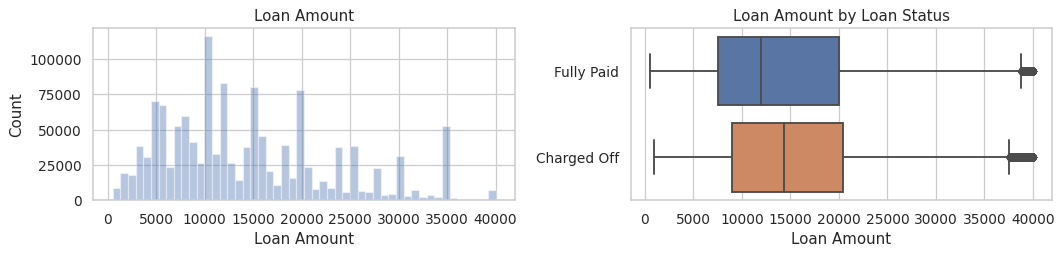

In [28]:
plot_var('loan_amnt', 'Loan Amount', continuous=True)

In [29]:
loans.groupby('loan_status')['loan_amnt'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,268559.0,15565.055444,8814.560077,900.0,9000.0,14350.0,20400.0,40000.0
Fully Paid,1076751.0,14134.369808,8669.028973,500.0,7500.0,12000.0,20000.0,40000.0


In [30]:
loans['term'].value_counts(dropna=False)

term
36 months    1020743
60 months     324567
Name: count, dtype: int64

In [31]:
loans['term'] = loans['term'].apply(lambda s: np.int8(s.split()[0]))

In [32]:
loans['term'].value_counts(normalize=True)

term
36    0.758742
60    0.241258
Name: proportion, dtype: float64

In [33]:
loans.groupby('term')['loan_status'].value_counts(normalize=True).loc[:,'Charged Off']

term
36    0.159934
60    0.324454
Name: proportion, dtype: float64

In [34]:
loans['int_rate'].describe()

count    1.345310e+06
mean     1.323962e+01
std      4.768716e+00
min      5.310000e+00
25%      9.750000e+00
50%      1.274000e+01
75%      1.599000e+01
max      3.099000e+01
Name: int_rate, dtype: float64

/tmp/ipykernel_37/2326775928.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(loans.loc[loans[col_name].notnull(), col_name], kde=False, ax=ax1)


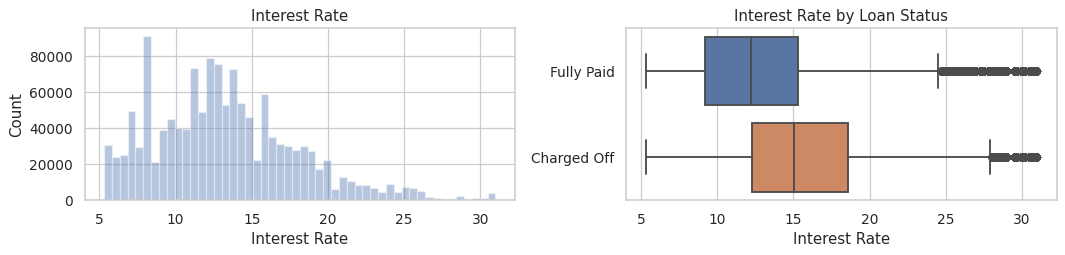

In [35]:
plot_var('int_rate', 'Interest Rate', continuous=True)

In [36]:
loans.groupby('loan_status')['int_rate'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,268559.0,15.710714,4.910387,5.31,12.29,15.05,18.55,30.99
Fully Paid,1076751.0,12.623288,4.527227,5.31,9.17,12.23,15.31,30.99


In [37]:
loans['installment'].describe()

count    1.345310e+06
mean     4.380755e+02
std      2.615126e+02
min      4.930000e+00
25%      2.484800e+02
50%      3.754300e+02
75%      5.807300e+02
max      1.719830e+03
Name: installment, dtype: float64

/tmp/ipykernel_37/2326775928.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(loans.loc[loans[col_name].notnull(), col_name], kde=False, ax=ax1)


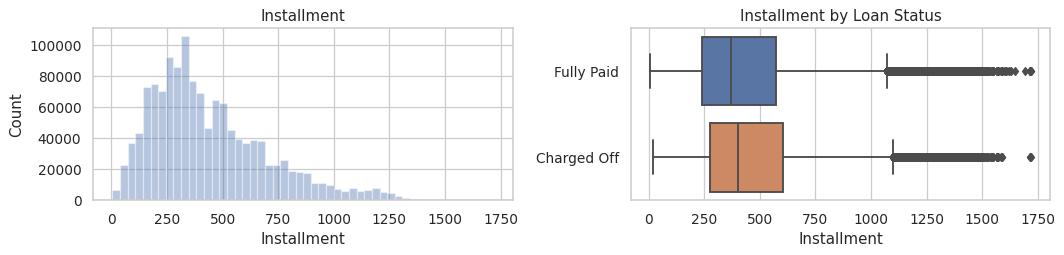

In [38]:
plot_var('installment', 'Installment', continuous=True)

In [39]:
loans.groupby('loan_status')['installment'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,268559.0,465.147994,262.774106,21.62,275.29,402.83,605.31,1717.63
Fully Paid,1076751.0,431.323226,260.759563,4.93,240.92,368.26,573.06,1719.83


In [40]:
print(sorted(loans['grade'].unique()))

['A', 'B', 'C', 'D', 'E', 'F', 'G']


In [41]:
print(sorted(loans['sub_grade'].unique()))

['A1', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3', 'B4', 'B5', 'C1', 'C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4', 'D5', 'E1', 'E2', 'E3', 'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5', 'G1', 'G2', 'G3', 'G4', 'G5']


In [42]:
loans.drop('grade', axis=1, inplace=True)

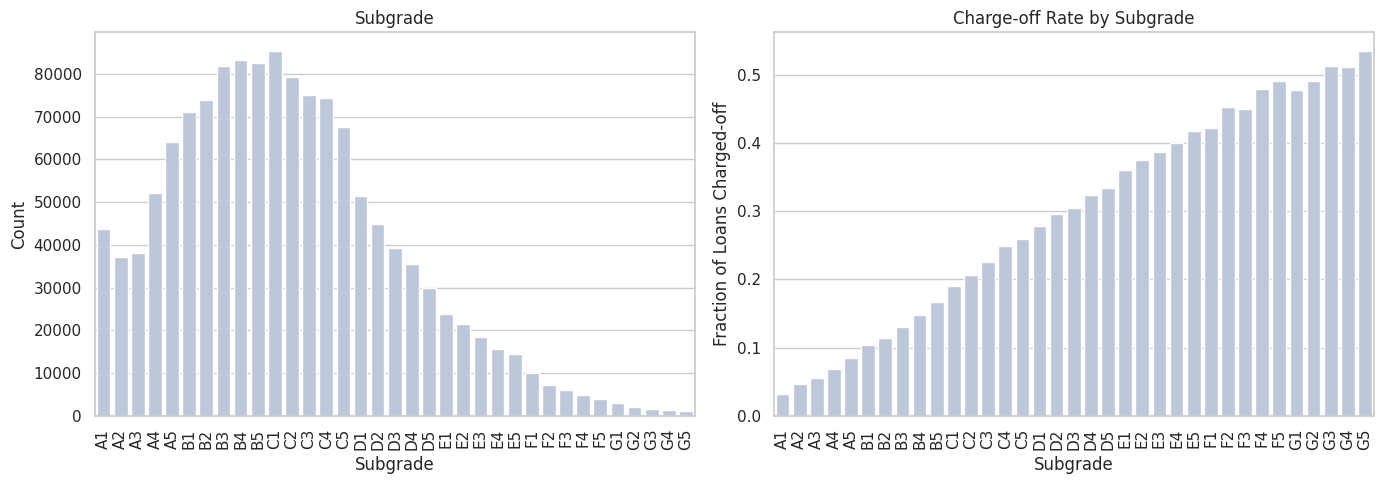

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_style("whitegrid")  # white background with grid

plt.figure(figsize=(14,5))

# Create the correct subgrade order: A1, A2, ..., G5
subgrade_order = [f"{g}{i}" for g in "ABCDEFG" for i in range(1,6)]

# --- Left plot: Count of loans by sub_grade ---
plt.subplot(1, 2, 1)
sns.countplot(
    data=loans,
    x='sub_grade',
    order=subgrade_order,
    color='#B7C6DF'   # solid blue
)
plt.title('Subgrade')
plt.xlabel('Subgrade')
plt.ylabel('Count')
plt.xticks(rotation=90)

# --- Right plot: Charge-off rate by sub_grade ---
plt.subplot(1, 2, 2)
chargeoff_rate = (
    loans.groupby('sub_grade')['loan_status']
    .apply(lambda x: (x == 'Charged Off').mean())
    .reindex(subgrade_order)
)

sns.barplot(
    x=chargeoff_rate.index,
    y=chargeoff_rate.values,
    color='#B7C6DF'   # solid blue
)
plt.title('Charge-off Rate by Subgrade')
plt.xlabel('Subgrade')
plt.ylabel('Fraction of Loans Charged-off')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


In [44]:
loans['emp_title'].describe()

count     1259525
unique     378353
top       Teacher
freq        21268
Name: emp_title, dtype: object

In [45]:
loans.drop(labels='emp_title', axis=1, inplace=True)

In [46]:
loans['emp_length'].value_counts(dropna=False).sort_index()

emp_length
1 year        88494
10+ years    442199
2 years      121743
3 years      107597
4 years       80556
5 years       84154
6 years       62733
7 years       59624
8 years       60701
9 years       50937
< 1 year     108061
NaN           78511
Name: count, dtype: int64

In [47]:
loans['emp_length'].replace(to_replace='10+ years', value='10 years', inplace=True)

/tmp/ipykernel_37/3799068326.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loans['emp_length'].replace(to_replace='10+ years', value='10 years', inplace=True)


In [48]:
loans['emp_length'].replace('< 1 year', '0 years', inplace=True)

/tmp/ipykernel_37/449194209.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loans['emp_length'].replace('< 1 year', '0 years', inplace=True)


In [49]:
def emp_length_to_int(s):
    if pd.isnull(s):
        return s
    else:
        return np.int8(s.split()[0])

In [50]:
loans['emp_length'] = loans['emp_length'].apply(emp_length_to_int)

In [51]:
loans['emp_length'].value_counts(dropna=False).sort_index()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


emp_length
0.0     108061
1.0      88494
2.0     121743
3.0     107597
4.0      80556
5.0      84154
6.0      62733
7.0      59624
8.0      60701
9.0      50937
10.0    442199
NaN      78511
Name: count, dtype: int64

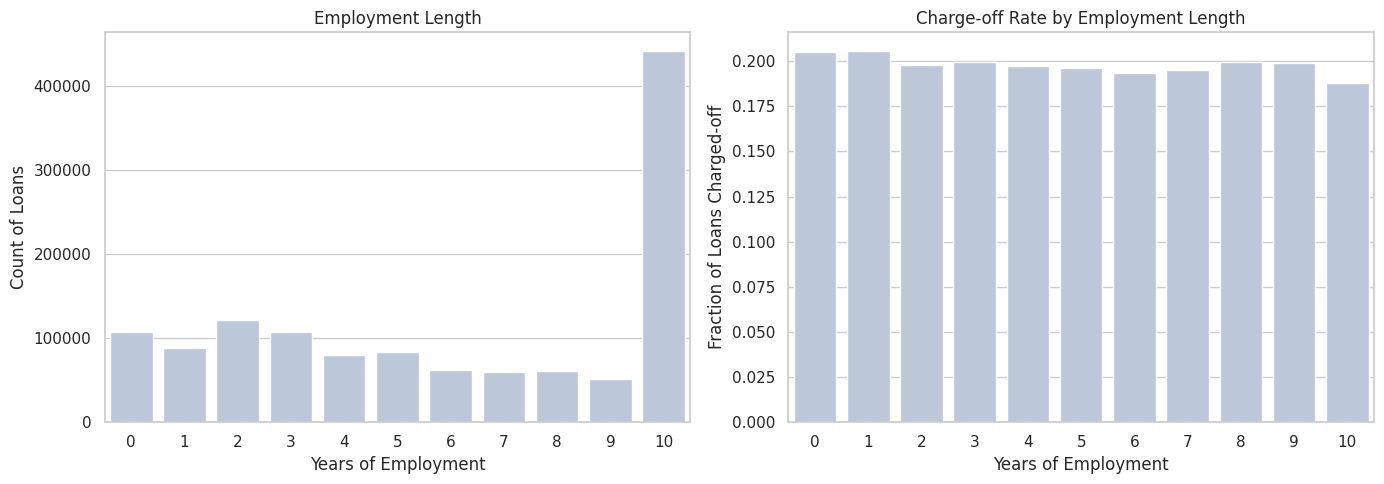

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(14,5))

# Create numeric employment length order (0 to 10 years)
emp_order = [i for i in range(0, 11)]  # 0,1,2,...,10

# Drop rows with missing emp_length just for plotting
loans_emp = loans.dropna(subset=['emp_length']).copy()
loans_emp['emp_length'] = loans_emp['emp_length'].astype(int)

# --- Left plot: Count of loans by employment length ---
plt.subplot(1, 2, 1)
sns.countplot(
    data=loans_emp,
    x='emp_length',
    order=emp_order,
    color="#B7C6DF"
)
plt.title('Employment Length')
plt.xlabel('Years of Employment')
plt.ylabel('Count of Loans')
plt.xticks(rotation=0)

# --- Right plot: Charge-off rate by employment length ---
plt.subplot(1, 2, 2)
chargeoff_rate_emp = (
    loans_emp.groupby('emp_length')['loan_status']
    .apply(lambda x: (x == 'Charged Off').mean())
    .reindex(emp_order)
)

sns.barplot(
    x=chargeoff_rate_emp.index,
    y=chargeoff_rate_emp.values,
    order=emp_order,
    color="#B7C6DF"
)
plt.title('Charge-off Rate by Employment Length')
plt.xlabel('Years of Employment')
plt.ylabel('Fraction of Loans Charged-off')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [53]:
loans['home_ownership'].value_counts(dropna=False)

home_ownership
MORTGAGE    665579
RENT        534421
OWN         144832
ANY            286
OTHER          144
NONE            48
Name: count, dtype: int64

In [54]:
loans['home_ownership'].replace(['NONE', 'ANY'], 'OTHER', inplace=True)

/tmp/ipykernel_37/1923515269.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loans['home_ownership'].replace(['NONE', 'ANY'], 'OTHER', inplace=True)


In [55]:
loans['home_ownership'].value_counts(dropna=False)

home_ownership
MORTGAGE    665579
RENT        534421
OWN         144832
OTHER          478
Name: count, dtype: int64

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_categorical_var(df, col_name, full_name):
    """
    Visualize a categorical variable:
    - Left: counts of each category
    - Right: fraction of loans charged off per category
    """
    plt.figure(figsize=(12,4))
    
    # --- Left plot: counts ---
    plt.subplot(1, 2, 1)
    order = sorted(df[col_name].dropna().unique())  # ensure consistent order
    sns.countplot(
        data=df, 
        x=col_name, 
        order=order, 
        color='#5975A4', 
        saturation=1
    )
    plt.xlabel(full_name)
    plt.ylabel('Count')
    plt.title(full_name)
    
    # --- Right plot: charge-off rate ---
    plt.subplot(1, 2, 2)
    charge_off_rates = df.groupby(col_name)['loan_status'].apply(lambda x: (x == 'Charged Off').mean())
    charge_off_rates = charge_off_rates.reindex(order)  # maintain same order
    sns.barplot(
        x=charge_off_rates.index, 
        y=charge_off_rates.values, 
        color='#5975A4', 
        saturation=1
    )
    plt.xlabel(full_name)
    plt.ylabel('Fraction of Loans Charged-off')
    plt.title('Charge-off Rate by ' + full_name)
    
    plt.tight_layout()
    plt.show()


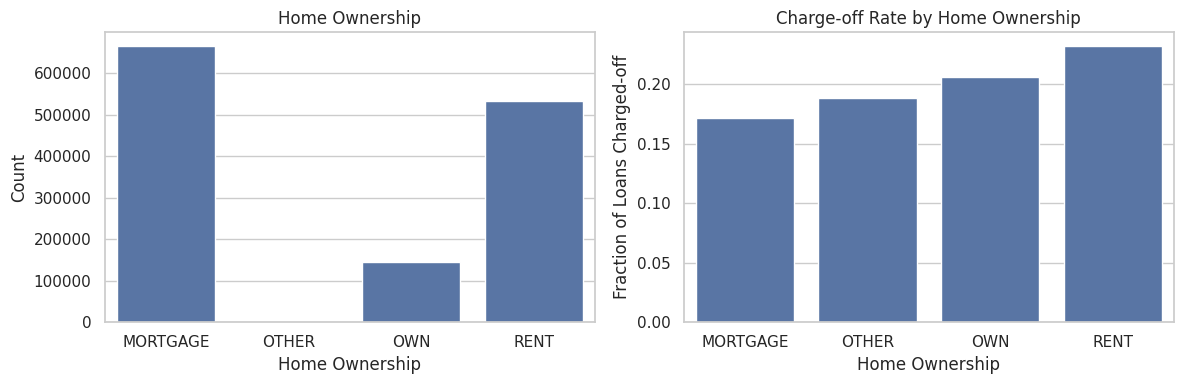

In [57]:
plot_categorical_var(loans, 'home_ownership', 'Home Ownership')

In [58]:
loans.groupby('home_ownership')['loan_status'].value_counts(normalize=True).loc[:,'Charged Off']

home_ownership
MORTGAGE    0.172077
OTHER       0.188285
OWN         0.206198
RENT        0.232165
Name: proportion, dtype: float64

In [59]:
loans['annual_inc'].describe()

count    1.345310e+06
mean     7.624764e+04
std      6.992510e+04
min      0.000000e+00
25%      4.578000e+04
50%      6.500000e+04
75%      9.000000e+04
max      1.099920e+07
Name: annual_inc, dtype: float64

In [60]:
loans['log_annual_inc'] = loans['annual_inc'].apply(lambda x: np.log10(x+1))

In [61]:
loans.drop('annual_inc', axis=1, inplace=True)

In [62]:
loans['log_annual_inc'].describe()

count    1.345310e+06
mean     4.812814e+00
std      2.477200e-01
min      0.000000e+00
25%      4.660685e+00
50%      4.812920e+00
75%      4.954247e+00
max      7.041361e+00
Name: log_annual_inc, dtype: float64

/tmp/ipykernel_37/2326775928.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(loans.loc[loans[col_name].notnull(), col_name], kde=False, ax=ax1)


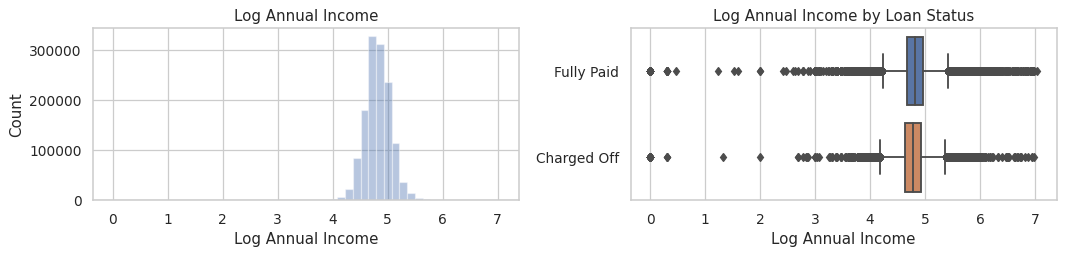

In [63]:
plot_var('log_annual_inc', 'Log Annual Income', continuous=True)

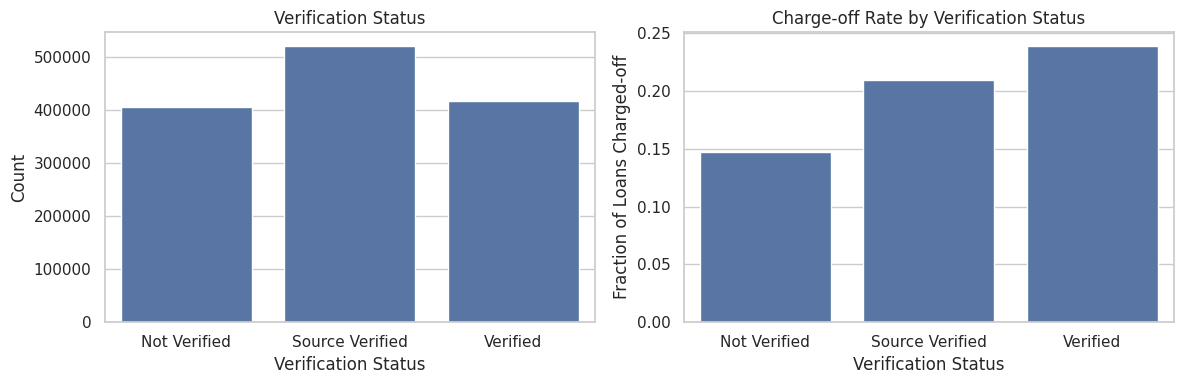

In [64]:
plot_categorical_var(loans, 'verification_status', 'Verification Status')

In [65]:
loans['purpose'].value_counts()

purpose
debt_consolidation    780321
credit_card           295279
home_improvement       87504
other                  77875
major_purchase         29425
medical                15554
small_business         15416
car                    14585
moving                  9480
vacation                9065
house                   7253
wedding                 2294
renewable_energy         933
educational              326
Name: count, dtype: int64

In [66]:
loans.groupby('purpose')['loan_status'].value_counts(normalize=True).loc[:,'Charged Off'].sort_values()

purpose
wedding               0.121622
car                   0.146795
credit_card           0.169270
educational           0.171779
home_improvement      0.177158
major_purchase        0.185998
vacation              0.191726
other                 0.210401
debt_consolidation    0.211469
medical               0.217757
house                 0.218806
moving                0.233544
renewable_energy      0.236870
small_business        0.297094
Name: proportion, dtype: float64

In [67]:
loans['title'].describe()

count                1328650
unique                 61681
top       Debt consolidation
freq                  660960
Name: title, dtype: object

In [68]:
loans['title'].value_counts().head(10)

title
Debt consolidation         660960
Credit card refinancing    249910
Home improvement            75073
Other                       66778
Major purchase              24045
Debt Consolidation          15695
Medical expenses            13576
Business                    11750
Car financing               11220
Vacation                     8046
Name: count, dtype: int64

In [69]:
loans.drop('title', axis=1, inplace=True)

In [70]:
loans['zip_code'].nunique()

943

In [71]:
loans['addr_state'].nunique()

51

In [72]:
loans.drop(labels='zip_code', axis=1, inplace=True)

In [73]:
loans.groupby('addr_state')['loan_status'].value_counts(normalize=True).loc[:,'Charged Off'].sort_values()

addr_state
DC    0.132086
ME    0.138424
VT    0.139517
IA    0.142857
OR    0.143850
NH    0.145759
WV    0.155187
CO    0.155269
WA    0.157565
SC    0.162769
KS    0.167438
WY    0.167693
MT    0.168716
UT    0.170586
CT    0.173763
RI    0.178675
IL    0.180974
WI    0.183510
GA    0.183927
ID    0.188277
MA    0.190528
CA    0.196104
AZ    0.196299
AK    0.196552
MN    0.197430
DE    0.197462
TX    0.198223
VA    0.199422
HI    0.202013
MI    0.202957
ND    0.204744
OH    0.205283
NC    0.207839
PA    0.207921
KY    0.209829
NJ    0.211212
MO    0.212935
MD    0.213085
SD    0.213227
NM    0.213665
TN    0.214079
IN    0.214082
FL    0.214746
NV    0.219223
NY    0.220435
LA    0.231821
OK    0.234753
AL    0.236321
AR    0.240868
NE    0.251813
MS    0.260777
Name: proportion, dtype: float64

In [74]:
loans['dti'].describe()

count    1.344936e+06
mean     1.828267e+01
std      1.116045e+01
min     -1.000000e+00
25%      1.179000e+01
50%      1.761000e+01
75%      2.406000e+01
max      9.990000e+02
Name: dti, dtype: float64

/tmp/ipykernel_37/3879297255.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(loans.loc[loans['dti'].notnull() & (loans['dti']<60), 'dti'], kde=False)


Text(0.5, 1.0, 'Debt-to-income Ratio')

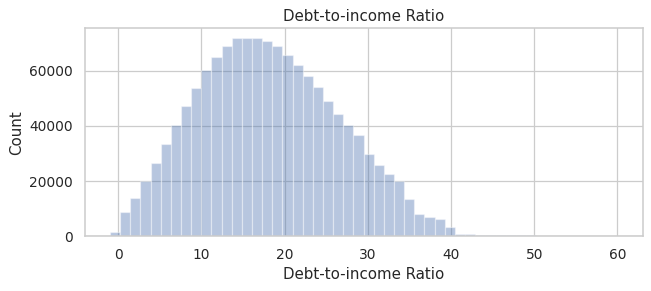

In [75]:
plt.figure(figsize=(8,3), dpi=90)
sns.distplot(loans.loc[loans['dti'].notnull() & (loans['dti']<60), 'dti'], kde=False)
plt.xlabel('Debt-to-income Ratio')
plt.ylabel('Count')
plt.title('Debt-to-income Ratio')

In [76]:
(loans['dti']>=60).sum()

1715

In [77]:
loans.groupby('loan_status')['dti'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,268488.0,20.171196,11.831747,0.0,13.55,19.76,26.31,999.0
Fully Paid,1076448.0,17.811629,10.935927,-1.0,11.43,17.11,23.44,999.0


In [78]:
loans['earliest_cr_line'].isnull().any()

False

In [79]:
loans['earliest_cr_line'] = loans['earliest_cr_line'].apply(lambda s: int(s[-4:]))

In [80]:
loans['earliest_cr_line'].describe()

count    1.345310e+06
mean     1.998693e+03
std      7.608258e+00
min      1.934000e+03
25%      1.995000e+03
50%      2.000000e+03
75%      2.004000e+03
max      2.015000e+03
Name: earliest_cr_line, dtype: float64

/tmp/ipykernel_37/2326775928.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(loans.loc[loans[col_name].notnull(), col_name], kde=False, ax=ax1)


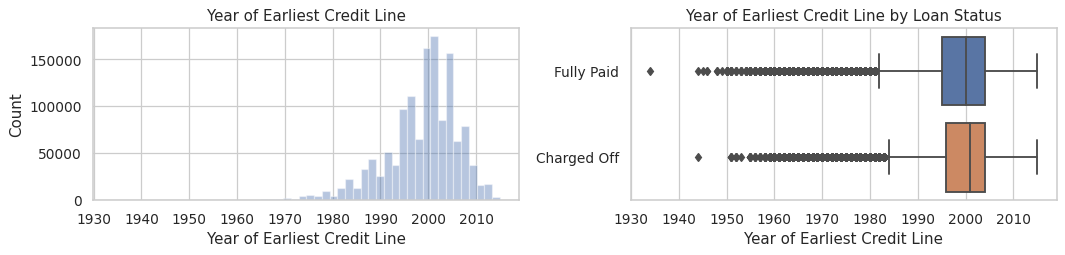

In [81]:
plot_var('earliest_cr_line', 'Year of Earliest Credit Line', continuous=True)

In [82]:
loans[['fico_range_low', 'fico_range_high']].describe()

,fico_range_low,fico_range_high
count,1.345310e+06,1.345310e+06
mean,6.961850e+02,7.001852e+02
std,3.185251e+01,3.185316e+01
min,6.250000e+02,6.290000e+02
25%,6.700000e+02,6.740000e+02
50%,6.900000e+02,6.940000e+02
75%,7.100000e+02,7.140000e+02
max,8.450000e+02,8.500000e+02


In [83]:
loans[['fico_range_low','fico_range_high']].corr()

,fico_range_low,fico_range_high
fico_range_low,1.0,1.0
fico_range_high,1.0,1.0


In [84]:
loans['fico_score'] = 0.5*loans['fico_range_low'] + 0.5*loans['fico_range_high']

In [85]:
loans.drop(['fico_range_high', 'fico_range_low'], axis=1, inplace=True)

/tmp/ipykernel_37/2326775928.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(loans.loc[loans[col_name].notnull(), col_name], kde=False, ax=ax1)


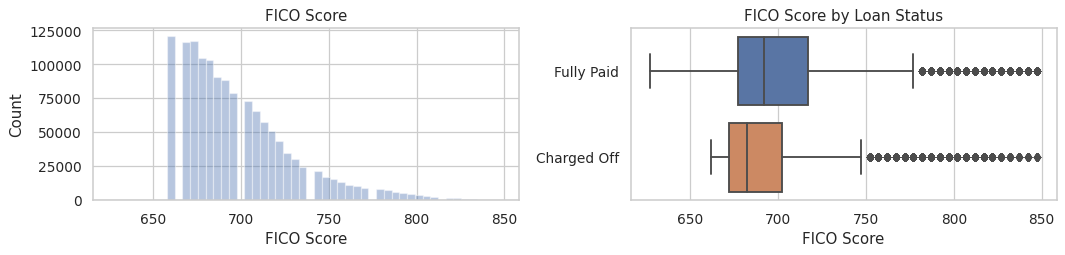

In [86]:
plot_var('fico_score', 'FICO Score', continuous=True)

In [87]:
loans.groupby('loan_status')['fico_score'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,268559.0,689.850145,25.948737,662.0,672.0,682.0,702.0,847.5
Fully Paid,1076751.0,700.263982,32.834008,627.0,677.0,692.0,717.0,847.5


Text(0.5, 1.0, 'Number of Open Credit Lines')

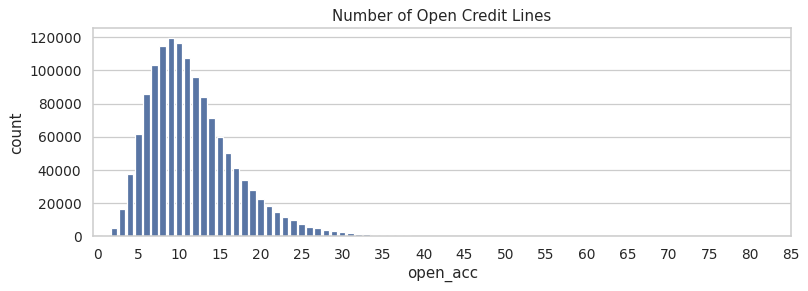

In [88]:
plt.figure(figsize=(10,3), dpi=90)
sns.countplot(x='open_acc', data=loans, order=sorted(loans['open_acc'].dropna().unique()), color='#5975A4', saturation=1)
_, _ = plt.xticks(np.arange(0, 90, 5), np.arange(0, 90, 5))
plt.title('Number of Open Credit Lines')

In [89]:
loans.groupby('loan_status')['open_acc'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,268559.0,11.901269,5.637964,0.0,8.0,11.0,15.0,76.0
Fully Paid,1076751.0,11.516763,5.429354,0.0,8.0,11.0,14.0,90.0


In [90]:
loans['pub_rec'].value_counts().sort_index()

pub_rec
0.0     1117425
1.0      190789
2.0       24435
3.0        7399
4.0        2630
5.0        1266
6.0         636
7.0         283
8.0         160
9.0          83
10.0         57
11.0         40
12.0         27
13.0         18
14.0          5
15.0          9
16.0          5
17.0          3
18.0          6
19.0          5
20.0          3
21.0          6
22.0          2
23.0          1
24.0          2
25.0          1
28.0          3
34.0          1
37.0          1
40.0          1
46.0          1
47.0          1
49.0          2
54.0          1
61.0          1
63.0          1
86.0          1
Name: count, dtype: int64

In [91]:
loans.groupby('loan_status')['pub_rec'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,268559.0,0.246843,0.656732,0.0,0.0,0.0,0.0,86.0
Fully Paid,1076751.0,0.207403,0.587118,0.0,0.0,0.0,0.0,63.0


/tmp/ipykernel_37/2326775928.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(loans.loc[loans[col_name].notnull(), col_name], kde=False, ax=ax1)


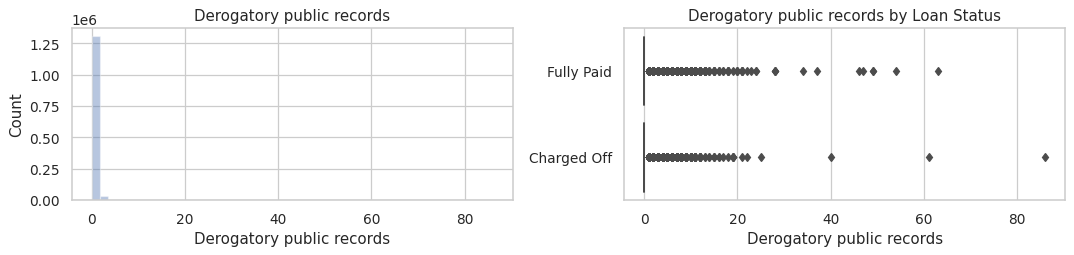

In [92]:
plot_var('pub_rec', 'Derogatory public records', continuous=True)

In [93]:
loans['revol_bal'].describe()

count    1.345310e+06
mean     1.624811e+04
std      2.232817e+04
min      0.000000e+00
25%      5.943000e+03
50%      1.113400e+04
75%      1.975575e+04
max      2.904836e+06
Name: revol_bal, dtype: float64

In [94]:
loans['log_revol_bal'] = loans['revol_bal'].apply(lambda x: np.log10(x+1))

In [95]:
loans.drop('revol_bal', axis=1, inplace=True)

/tmp/ipykernel_37/2326775928.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(loans.loc[loans[col_name].notnull(), col_name], kde=False, ax=ax1)


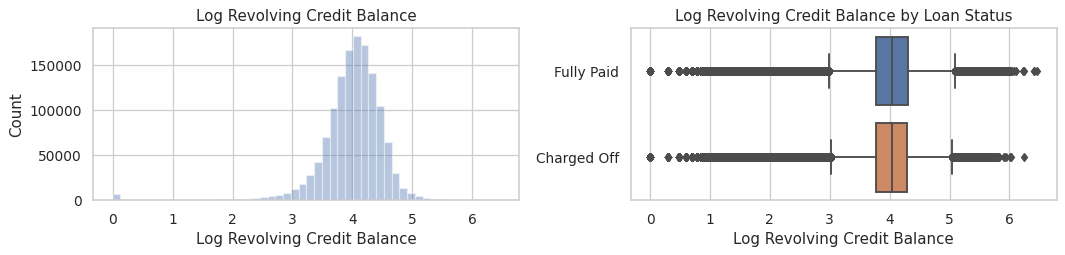

In [96]:
plot_var('log_revol_bal', 'Log Revolving Credit Balance', continuous=True)

In [97]:
loans['revol_util'].describe()

count    1.344453e+06
mean     5.181002e+01
std      2.452107e+01
min      0.000000e+00
25%      3.340000e+01
50%      5.220000e+01
75%      7.070000e+01
max      8.923000e+02
Name: revol_util, dtype: float64

/tmp/ipykernel_37/2326775928.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(loans.loc[loans[col_name].notnull(), col_name], kde=False, ax=ax1)


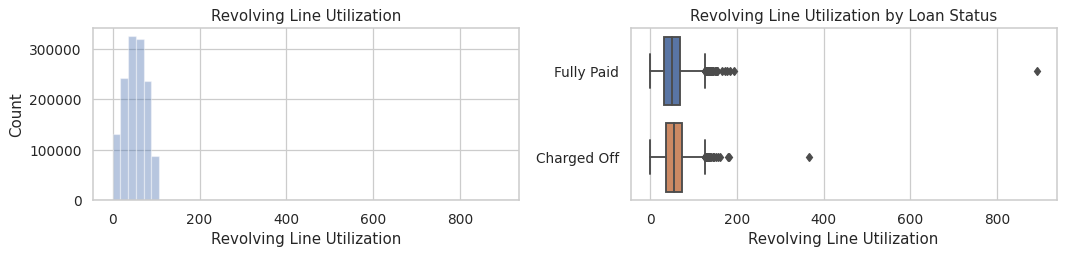

In [98]:
plot_var('revol_util', 'Revolving Line Utilization', continuous=True)

In [99]:
loans.groupby('loan_status')['revol_util'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,268379.0,54.758433,23.865982,0.0,37.4,55.5,73.1,366.6
Fully Paid,1076074.0,51.074671,24.626821,0.0,32.5,51.3,70.1,892.3


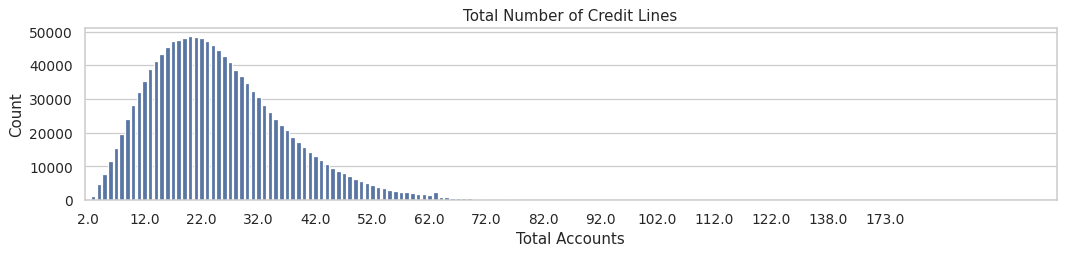

In [100]:
plt.figure(figsize=(12,3), dpi=90)
sns.countplot(
    x='total_acc',
    data=loans,
    order=sorted(loans['total_acc'].dropna().unique()),
    color='#5975A4',
    saturation=1
)

# Set xticks every 10 up to 175
plt.xticks(np.arange(0, 176, 10))
plt.title('Total Number of Credit Lines')
plt.xlabel('Total Accounts')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [101]:
loans.groupby('loan_status')['total_acc'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,268559.0,24.709356,12.117364,2.0,16.0,23.0,31.0,176.0
Fully Paid,1076751.0,25.048551,11.967683,2.0,16.0,23.0,32.0,162.0


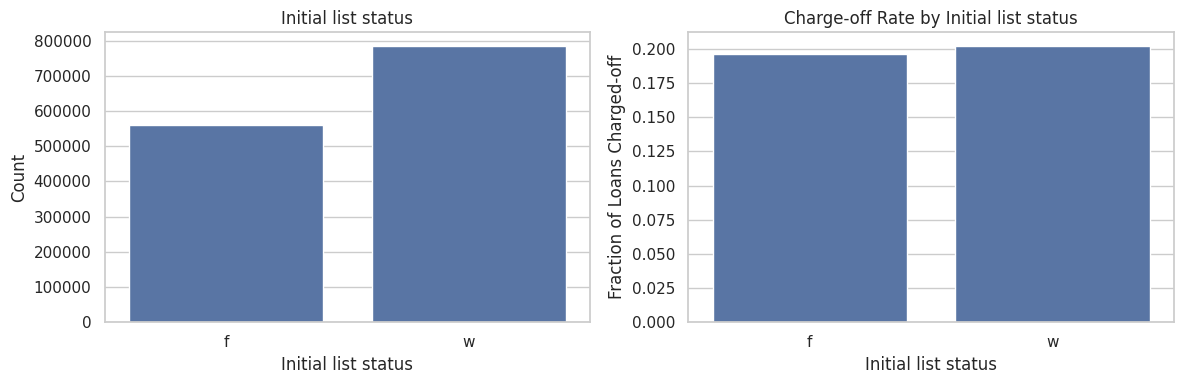

In [102]:
plot_categorical_var(loans, 'initial_list_status', 'Initial list status')

In [103]:
loans['application_type'].value_counts()

application_type
Individual    1319510
Joint App       25800
Name: count, dtype: int64

In [104]:
loans.groupby('application_type')['loan_status'].value_counts(normalize=True).loc[:,'Charged Off']

application_type
Individual    0.198721
Joint App     0.245891
Name: proportion, dtype: float64

In [105]:
loans['mort_acc'].describe()

count    1.298029e+06
mean     1.670783e+00
std      2.000444e+00
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      3.000000e+00
max      5.100000e+01
Name: mort_acc, dtype: float64

In [106]:
loans.groupby('loan_status')['mort_acc'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,261673.0,1.371032,1.825505,0.0,0.0,1.0,2.0,29.0
Fully Paid,1036356.0,1.746468,2.035279,0.0,0.0,1.0,3.0,51.0


In [107]:
loans['pub_rec_bankruptcies'].value_counts().sort_index()

pub_rec_bankruptcies
0.0     1176953
1.0      157696
2.0        7769
3.0        1583
4.0         396
5.0         141
6.0          46
7.0          15
8.0           9
9.0           3
11.0          1
12.0          1
Name: count, dtype: int64

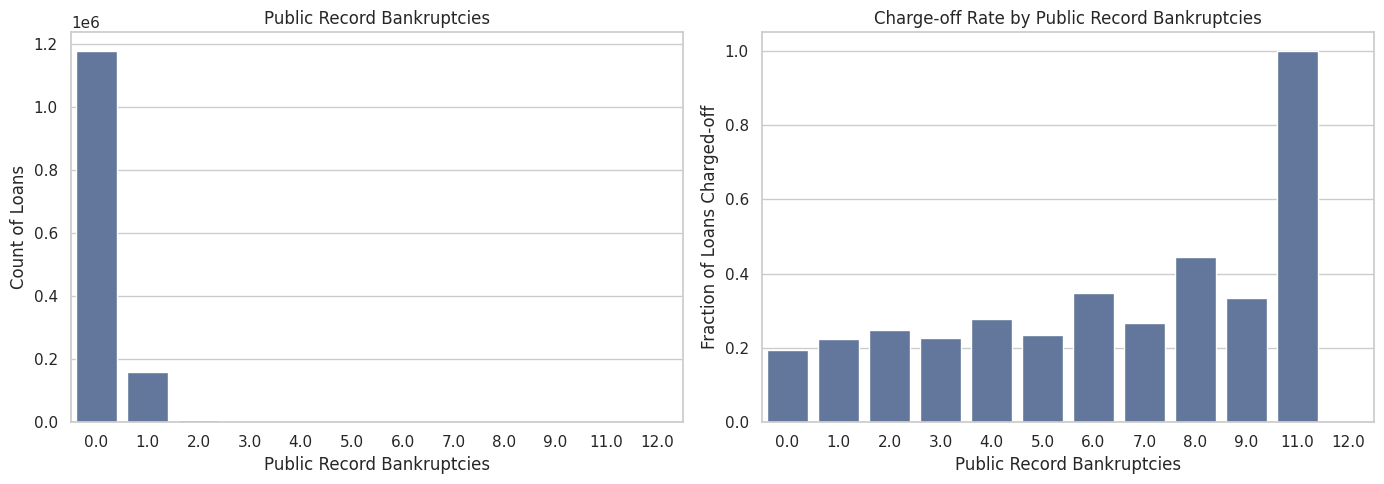

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 5))

# Drop missing values in pub_rec_bankruptcies for plotting
loans_prb = loans.dropna(subset=['pub_rec_bankruptcies']).copy()

# Get sorted unique categories to order plots
prb_order = sorted(loans_prb['pub_rec_bankruptcies'].unique())

# --- Left plot: Count of loans by pub_rec_bankruptcies ---
plt.subplot(1, 2, 1)
sns.countplot(
    data=loans_prb,
    x='pub_rec_bankruptcies',
    order=prb_order,
    color='#5975A4'
)
plt.title('Public Record Bankruptcies')
plt.xlabel('Public Record Bankruptcies')
plt.ylabel('Count of Loans')
plt.xticks(rotation=0)

# --- Right plot: Charge-off rate by pub_rec_bankruptcies ---
plt.subplot(1, 2, 2)
chargeoff_rate_prb = (
    loans_prb.groupby('pub_rec_bankruptcies')['loan_status']
    .apply(lambda x: (x == 'Charged Off').mean())
    .reindex(prb_order)
)

sns.barplot(
    x=chargeoff_rate_prb.index,
    y=chargeoff_rate_prb.values,
    order=prb_order,
    color='#5975A4'
)
plt.title('Charge-off Rate by Public Record Bankruptcies')
plt.xlabel('Public Record Bankruptcies')
plt.ylabel('Fraction of Loans Charged-off')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


In [109]:
loans['charged_off'] = (loans['loan_status'] == 'Charged Off').apply(np.uint8)
loans.drop('loan_status', axis=1, inplace=True)

In [110]:
loans.shape

(1345310, 25)

In [111]:
missing_fractions = loans.isnull().mean().sort_values(ascending=False) # Fraction of data missing for each variable

In [112]:
print(missing_fractions[missing_fractions > 0]) # Print variables that are missing data

emp_length              0.058359
mort_acc                0.035145
revol_util              0.000637
pub_rec_bankruptcies    0.000518
dti                     0.000278
dtype: float64


In [113]:
print(loans.columns)

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'sub_grade',
       'emp_length', 'home_ownership', 'verification_status', 'issue_d',
       'purpose', 'addr_state', 'dti', 'earliest_cr_line', 'open_acc',
       'pub_rec', 'revol_util', 'total_acc', 'initial_list_status',
       'application_type', 'mort_acc', 'pub_rec_bankruptcies',
       'log_annual_inc', 'fico_score', 'log_revol_bal', 'charged_off'],
      dtype='object')


In [114]:
loans = pd.get_dummies(loans, columns=['sub_grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'initial_list_status', 'application_type'], drop_first=True)

In [115]:
loans.shape

(1345310, 122)

In [116]:
loans.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'emp_length', 'issue_d',
       'dti', 'earliest_cr_line', 'open_acc', 'pub_rec',
       ...
       'addr_state_TX', 'addr_state_UT', 'addr_state_VA', 'addr_state_VT',
       'addr_state_WA', 'addr_state_WI', 'addr_state_WV', 'addr_state_WY',
       'initial_list_status_w', 'application_type_Joint App'],
      dtype='object', length=122)

In [117]:
X = loans.drop('charged_off', axis=1)
y = loans['charged_off']

In [118]:
loans['charged_off'].value_counts(normalize=True, dropna=False)

charged_off
0    0.800374
1    0.199626
Name: proportion, dtype: float64

In [119]:
loans.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'emp_length', 'issue_d',
       'dti', 'earliest_cr_line', 'open_acc', 'pub_rec',
       ...
       'addr_state_TX', 'addr_state_UT', 'addr_state_VA', 'addr_state_VT',
       'addr_state_WA', 'addr_state_WI', 'addr_state_WV', 'addr_state_WY',
       'initial_list_status_w', 'application_type_Joint App'],
      dtype='object', length=122)

In [168]:
# Save as CSV
loans.to_csv('loans_cleaned.csv', index=False)

In [169]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1345310 entries, 0 to 2260697
Columns: 122 entries, loan_amnt to application_type_Joint App
dtypes: bool(104), float64(14), int64(1), int8(1), object(1), uint8(1)
memory usage: 310.5+ MB


In [171]:
loans_cleaned = pd.read_csv('/kaggle/working/loans_cleaned.csv')

In [172]:
loans_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1345310 entries, 0 to 1345309
Columns: 122 entries, loan_amnt to application_type_Joint App
dtypes: bool(104), float64(14), int64(3), object(1)
memory usage: 318.2+ MB


In [120]:
loans['issue_d'].isnull().any()

False

In [121]:
loans['issue_d'] = pd.to_datetime(loans['issue_d'])

/tmp/ipykernel_37/137821621.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  loans['issue_d'] = pd.to_datetime(loans['issue_d'])


In [122]:
loans['issue_d'].sample(5)

85448     2015-10-01
1764453   2013-12-01
287491    2015-05-01
1842806   2013-06-01
1109877   2016-01-01
Name: issue_d, dtype: datetime64[ns]

In [123]:
loans['issue_d'].describe()

count                          1345310
mean     2015-06-06 17:48:20.835048960
min                2007-06-01 00:00:00
25%                2014-07-01 00:00:00
50%                2015-08-01 00:00:00
75%                2016-07-01 00:00:00
max                2018-12-01 00:00:00
Name: issue_d, dtype: object

Text(0.5, 1.0, 'Loans Funded per Year')

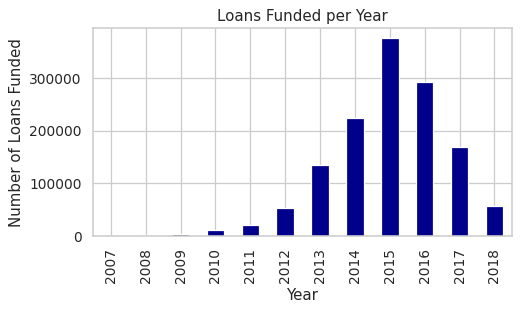

In [124]:
plt.figure(figsize=(6,3), dpi=90)
loans['issue_d'].dt.year.value_counts().sort_index().plot.bar(color='darkblue')
plt.xlabel('Year')
plt.ylabel('Number of Loans Funded')
plt.title('Loans Funded per Year')

In [125]:
loans_train = loans.loc[loans['issue_d'] < loans['issue_d'].quantile(0.9)]
loans_test  = loans.loc[loans['issue_d'] >= loans['issue_d'].quantile(0.9)]

In [126]:
train_cutoff = loans_train['issue_d'].quantile(0.8)
loans_train_final = loans_train.loc[loans_train['issue_d'] < train_cutoff]
loans_val = loans_train.loc[loans_train['issue_d'] >= train_cutoff]

In [127]:
print('Number of loans in the partition:   ', loans_train_final.shape[0] + loans_test.shape[0]+loans_val.shape[0])
print('Number of loans in the full dataset:', loans.shape[0])

Number of loans in the partition:    1345310
Number of loans in the full dataset: 1345310


In [128]:
loans_test.shape[0] / loans.shape[0]

0.11111639696426846

In [129]:
loans_train_final.shape[0]/loans.shape[0]

0.6976362325411987

In [130]:
loans_val.shape[0]/loans.shape[0]

0.19124737049453286

In [131]:
loans_train_final['issue_d'].describe()

count                           938537
mean     2014-09-04 08:09:13.576470784
min                2007-06-01 00:00:00
25%                2014-01-01 00:00:00
50%                2015-01-01 00:00:00
75%                2015-09-01 00:00:00
max                2016-03-01 00:00:00
Name: issue_d, dtype: object

In [132]:
loans_test['issue_d'].describe()

count                           149486
mean     2017-11-23 13:15:22.119797248
min                2017-06-01 00:00:00
25%                2017-08-01 00:00:00
50%                2017-11-01 00:00:00
75%                2018-03-01 00:00:00
max                2018-12-01 00:00:00
Name: issue_d, dtype: object

In [133]:
loans_val.drop('issue_d', axis=1, inplace=True)

/tmp/ipykernel_37/2617233787.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loans_val.drop('issue_d', axis=1, inplace=True)


In [153]:
loans_train_final.drop('issue_d', axis=1, inplace=True)
loans_test.drop('issue_d', axis=1, inplace=True)

/tmp/ipykernel_37/1763427145.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loans_train_final.drop('issue_d', axis=1, inplace=True)
/tmp/ipykernel_37/1763427145.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loans_test.drop('issue_d', axis=1, inplace=True)


In [154]:
y_train = loans_train_final['charged_off']
y_val   = loans_val['charged_off']
y_test  = loans_test['charged_off']

X_train = loans_train_final.drop('charged_off', axis=1).copy()
X_val   = loans_val.drop('charged_off', axis=1).copy()
X_test  = loans_test.drop('charged_off', axis=1).copy()

In [155]:
linear_dep = pd.DataFrame()

In [156]:
for col in X_train.columns:
    linear_dep.loc[col, 'pearson_corr'] = X_train[col].corr(y_train)
linear_dep['abs_pearson_corr'] = abs(linear_dep['pearson_corr'])

In [157]:
from sklearn.feature_selection import f_classif
for col in X_train.columns:
    mask = X_train[col].notnull()
    (linear_dep.loc[col, 'F'], linear_dep.loc[col, 'p_value']) = f_classif(pd.DataFrame(X_train.loc[mask, col]), y_train.loc[mask])

In [158]:
linear_dep.sort_values('abs_pearson_corr', ascending=False, inplace=True)
linear_dep.drop('abs_pearson_corr', axis=1, inplace=True)

In [159]:
linear_dep.reset_index(inplace=True)
linear_dep.rename(columns={'index':'variable'}, inplace=True)

In [160]:
linear_dep.head(20)

,variable,pearson_corr,F,p_value
0,int_rate,0.258185,67030.725822,0.0
1,term,0.201776,39833.102757,0.0
2,fico_score,-0.127396,15483.444572,0.0
3,dti,0.108410,11161.280823,0.0
4,sub_grade_A5,-0.065252,4013.188582,0.0
5,sub_grade_A4,-0.065111,3995.757147,0.0
6,log_annual_inc,-0.064269,3892.713541,0.0
7,sub_grade_A2,-0.062271,3653.518377,0.0
8,loan_amnt,0.061860,3605.230273,0.0
9,sub_grade_E2,0.061833,3602.045291,0.0


In [161]:
linear_dep.tail(20)

,variable,pearson_corr,F,p_value
100,sub_grade_C2,0.003402,10.864244,0.000980
101,addr_state_MT,-0.003373,10.680269,0.001083
102,addr_state_WY,-0.003334,10.431907,0.001239
103,addr_state_RI,-0.002980,8.332197,0.003895
104,purpose_medical,0.002841,7.577763,0.005909
105,addr_state_UT,-0.002548,6.090692,0.013590
106,addr_state_SD,0.002501,5.869715,0.015404
107,purpose_renewable_energy,0.002310,5.008955,0.025217
108,addr_state_HI,0.001468,2.022422,0.154992
109,addr_state_VA,0.001437,1.937609,0.163929


In [162]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV

In [143]:
from sklearn.linear_model import SGDClassifier

In [163]:
pipeline_sgdlogreg = Pipeline([
    ('imputer', SimpleImputer(strategy='mean', copy=False)),  # Mean imputation
    ('scaler', StandardScaler(copy=False)),
    ('model', SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3, random_state=1, warm_start=True))
])

In [164]:
param_grid_sgdlogreg = {
    'model__alpha': [10**-5, 10**-2, 10**1],
    'model__penalty': ['l1', 'l2']
}

In [165]:
grid_sgdlogreg = GridSearchCV(estimator=pipeline_sgdlogreg, param_grid=param_grid_sgdlogreg, scoring='roc_auc', n_jobs=-1, pre_dispatch='2*n_jobs', cv=5, verbose=1, return_train_score=False)

In [167]:
grid_sgdlogreg.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('imputer', SimpleImputer(copy=False)),
                                       ('scaler', StandardScaler(copy=False)),
                                       ('model',
                                        SGDClassifier(loss='log_loss',
                                                      random_state=1,
                                                      warm_start=True))]),
             n_jobs=-1,
             param_grid={'model__alpha': [1e-05, 0.01, 10],
                         'model__penalty': ['l1', 'l2']},
             scoring='roc_auc', verbose=1)

In [168]:
grid_sgdlogreg.best_score_

0.712581827587454

In [169]:
grid_sgdlogreg.best_params_

{'model__alpha': 0.01, 'model__penalty': 'l2'}

In [170]:
best_params = grid_sgdlogreg.best_params_
print(best_params)

{'model__alpha': 0.01, 'model__penalty': 'l2'}


In [171]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Create final pipeline with best params + class weights
final_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean', copy=False)),
    ('scaler', StandardScaler(copy=False)),
    ('model', SGDClassifier(
        loss='log_loss',
        max_iter=1000,
        tol=1e-3,
        random_state=1,
        warm_start=True,
        alpha=best_params['model__alpha'],
        penalty=best_params['model__penalty'],
        class_weight='balanced'  # Handles imbalance
    ))
])

In [172]:
import numpy as np
X_train_val = np.vstack([X_train, X_val])
y_train_val = np.hstack([y_train, y_val])
final_pipeline.fit(X_train_val, y_train_val)

Pipeline(steps=[('imputer', SimpleImputer(copy=False)),
                ('scaler', StandardScaler(copy=False)),
                ('model',
                 SGDClassifier(alpha=0.01, class_weight='balanced',
                               loss='log_loss', random_state=1,
                               warm_start=True))])

In [173]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predict on test set
y_test_pred = final_pipeline.predict(X_test)
y_test_proba = final_pipeline.predict_proba(X_test)[:,1]

# Compute metrics
print("=== Test Set Metrics ===")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))
print("ROC AUC:", roc_auc_score(y_test, y_test_proba))

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(


=== Test Set Metrics ===
Accuracy: 0.635136400733179
Precision: 0.3135901888764235
Recall: 0.6738103886669088
F1 Score: 0.427993120228207
ROC AUC: 0.7040787777655168


In [174]:
from sklearn.ensemble import RandomForestClassifier

In [175]:
pipeline_rfc = Pipeline([
    ('imputer', SimpleImputer(strategy='mean', copy=False)),  # Default mean imputation
    ('model', RandomForestClassifier(n_jobs=-1, random_state=1))
])

In [176]:
param_grid_rfc = {
    'model__n_estimators': [50]}

In [177]:
grid_rfc = GridSearchCV(estimator=pipeline_rfc, param_grid=param_grid_rfc, scoring='roc_auc', n_jobs=-1, pre_dispatch='2*n_jobs', cv=5, verbose=1, return_train_score=False)

In [178]:
grid_rfc.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('imputer', SimpleImputer(copy=False)),
                                       ('model',
                                        RandomForestClassifier(n_jobs=-1,
                                                               random_state=1))]),
             n_jobs=-1, param_grid={'model__n_estimators': [50]},
             scoring='roc_auc', verbose=1)

In [179]:
grid_rfc.best_score_

0.661421345548721

In [180]:
best_params_rfc = grid_rfc.best_params_
print("Best parameters:", best_params_rfc)
print("Best ROC AUC (CV):", grid_rfc.best_score_)

Best parameters: {'model__n_estimators': 50}
Best ROC AUC (CV): 0.661421345548721


In [181]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

final_pipeline_rfc = Pipeline([
    ('imputer', SimpleImputer(strategy='mean', copy=False)),
    ('model', RandomForestClassifier(
        n_estimators=best_params_rfc.get('model__n_estimators', 100),  # default if not in grid
        max_depth=best_params_rfc.get('model__max_depth', None),
        min_samples_split=best_params_rfc.get('model__min_samples_split', 2),
        min_samples_leaf=best_params_rfc.get('model__min_samples_leaf', 1),
        max_features=best_params_rfc.get('model__max_features', 'auto'),
        random_state=1,
        n_jobs=-1,
        class_weight='balanced'  # Optional: handle class imbalance
    ))
])

In [182]:
import numpy as np

X_train_val = np.vstack([X_train, X_val])
y_train_val = np.hstack([y_train, y_val])

final_pipeline_rfc.fit(X_train_val, y_train_val)

/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


Pipeline(steps=[('imputer', SimpleImputer(copy=False)),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        max_features='auto', n_estimators=50,
                                        n_jobs=-1, random_state=1))])

In [183]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(pipeline, X, y, dataset_name="Dataset"):
    y_pred = pipeline.predict(X)
    y_proba = pipeline.predict_proba(X)[:,1]
    
    print(f"=== {dataset_name} Metrics ===")
    print("Accuracy:", accuracy_score(y, y_pred))
    print("Precision:", precision_score(y, y_pred))
    print("Recall:", recall_score(y, y_pred))
    print("F1 Score:", f1_score(y, y_pred))
    print("ROC AUC:", roc_auc_score(y, y_proba))
    print("\n")

# Training metrics
evaluate_model(final_pipeline_rfc, X_train, y_train, "Training")
# Validation metrics
evaluate_model(final_pipeline_rfc, X_val, y_val, "Validation")
# Test metrics
evaluate_model(final_pipeline_rfc, X_test, y_test, "Test")

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(


=== Training Metrics ===
Accuracy: 0.9995674118335239
Precision: 1.0
Recall: 0.9976812190162886
F1 Score: 0.9988392637615858
ROC AUC: 0.9999999987357219




/usr/local/lib/python3.11/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(


=== Validation Metrics ===
Accuracy: 0.9995335947793709
Precision: 1.0
Recall: 0.998100785008863
F1 Score: 0.9990494898929092
ROC AUC: 0.9999999985730831




/usr/local/lib/python3.11/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(


=== Test Metrics ===
Accuracy: 0.7971649519018503
Precision: 0.4943181818181818
Recall: 0.05458508073836806
F1 Score: 0.09831385493799626
ROC AUC: 0.694579141707176




In [184]:
from sklearn.neighbors import KNeighborsClassifier

In [185]:
pipeline_knn = Pipeline([
    ('imputer', SimpleImputer(strategy='mean', copy=False)),
    ('scaler', StandardScaler(copy=False)),
    ('lda', LinearDiscriminantAnalysis()),
    ('model', KNeighborsClassifier(n_jobs=-1))
])

In [186]:
print(X_train.shape)  # number of features
print(np.unique(y_train))  # number of classes

(938537, 120)
[0 1]


In [187]:
param_grid_knn = {
    'lda__n_components': [1], # Number of LDA components to keep
    'model__n_neighbors': [5, 25, 125] # The 'k' in k-nearest neighbors
}

In [188]:
grid_knn = GridSearchCV(estimator=pipeline_knn, param_grid=param_grid_knn, scoring='roc_auc', n_jobs=-1, pre_dispatch='2*n_jobs', cv=5, verbose=1, return_train_score=False)

In [189]:
grid_knn.fit(X_train, y_train)

Fitting 5 folds for each of 3 candidates, totalling 15 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('imputer', SimpleImputer(copy=False)),
                                       ('scaler', StandardScaler(copy=False)),
                                       ('lda', LinearDiscriminantAnalysis()),
                                       ('model',
                                        KNeighborsClassifier(n_jobs=-1))]),
             n_jobs=-1,
             param_grid={'lda__n_components': [1],
                         'model__n_neighbors': [5, 25, 125]},
             scoring='roc_auc', verbose=1)

In [190]:
grid_knn.best_score_

0.7039672235138029

In [191]:
grid_knn.best_params_

{'lda__n_components': 1, 'model__n_neighbors': 125}

In [192]:
best_params_knn = grid_knn.best_params_
print("Best parameters:", best_params_knn)
print("Best ROC AUC (CV):", grid_knn.best_score_)

Best parameters: {'lda__n_components': 1, 'model__n_neighbors': 125}
Best ROC AUC (CV): 0.7039672235138029


In [193]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

final_pipeline_knn = Pipeline([
    ('imputer', SimpleImputer(strategy='mean', copy=False)),
    ('scaler', StandardScaler(copy=False)),
    ('lda', LinearDiscriminantAnalysis(n_components=best_params_knn.get('lda__n_components', 1))),
    ('model', KNeighborsClassifier(
        n_neighbors=best_params_knn.get('model__n_neighbors', 5),
        n_jobs=-1
    ))
])

In [194]:
import numpy as np

X_train_val = np.vstack([X_train, X_val])
y_train_val = np.hstack([y_train, y_val])

final_pipeline_knn.fit(X_train_val, y_train_val)

Pipeline(steps=[('imputer', SimpleImputer(copy=False)),
                ('scaler', StandardScaler(copy=False)),
                ('lda', LinearDiscriminantAnalysis(n_components=1)),
                ('model', KNeighborsClassifier(n_jobs=-1, n_neighbors=125))])

In [195]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(pipeline, X, y, dataset_name="Dataset"):
    y_pred = pipeline.predict(X)
    y_proba = pipeline.predict_proba(X)[:,1]  # KNN supports predict_proba
    print(f"=== {dataset_name} Metrics ===")
    print("Accuracy:", accuracy_score(y, y_pred))
    print("Precision:", precision_score(y, y_pred))
    print("Recall:", recall_score(y, y_pred))
    print("F1 Score:", f1_score(y, y_pred))
    print("ROC AUC:", roc_auc_score(y, y_proba))
    print("\n")

# Training metrics
evaluate_model(final_pipeline_knn, X_train, y_train, "Training")
# Validation metrics
evaluate_model(final_pipeline_knn, X_val, y_val, "Validation")
# Test metrics
evaluate_model(final_pipeline_knn, X_test, y_test, "Test")

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(


=== Training Metrics ===
Accuracy: 0.8161404398547952
Precision: 0.5501484854484261
Recall: 0.07935256893518836
F1 Score: 0.13869935661627075
ROC AUC: 0.7252549824456492




/usr/local/lib/python3.11/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(


=== Validation Metrics ===
Accuracy: 0.7594359606198525
Precision: 0.5815011372251706
Recall: 0.07283489491010382
F1 Score: 0.12945511828743425
ROC AUC: 0.7041894286658223




/usr/local/lib/python3.11/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(


=== Test Metrics ===
Accuracy: 0.7957400693041489
Precision: 0.47549306776020306
Recall: 0.08040814978700922
F1 Score: 0.1375550785222009
ROC AUC: 0.6948731493563




In [196]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [197]:
# Binary classification: Lending Club dataset
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 4.360250611107303


In [198]:
pipeline_xgb = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),  # mean imputation
    ('scaler', StandardScaler()),                 # optional, helps a little
    ('model', XGBClassifier(
        random_state=1,
        n_jobs=-1,
        use_label_encoder=False,
        eval_metric='auc',
        scale_pos_weight=scale_pos_weight  # fixed class balancing
    ))
])

In [199]:
param_grid_xgb = {
    'model__n_estimators': [100, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1],
    'model__subsample': [0.8, 1],
    'model__colsample_bytree': [0.8, 1]
}

In [200]:
import time
from sklearn.model_selection import ParameterGrid

# Pick one parameter combination to test time
sample_params = list(ParameterGrid(param_grid_xgb))[0]

# Set parameters to pipeline
pipeline_xgb.set_params(**sample_params)

# Time a single fit
start = time.time()
pipeline_xgb.fit(X_train, y_train)
end = time.time()

single_fit_time = end - start
print(f"Time for one fit: {single_fit_time:.2f} seconds")

Time for one fit: 24.34 seconds


In [201]:
n_combinations = len(list(ParameterGrid(param_grid_xgb)))  # total parameter combos
cv_folds = 5  # because cv=5
total_fits = n_combinations * cv_folds

estimated_total_time = single_fit_time * total_fits
print(f"Estimated total time: {estimated_total_time/60:.2f} minutes")

Estimated total time: 97.35 minutes


In [197]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

model_xgb = xgb.XGBClassifier(use_label_encoder=False, eval_metric='auc')

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.1],
    'subsample': [0.7],
    'colsample_bytree': [0.7]
}

grid_xgb = GridSearchCV(model_xgb, param_grid, scoring='roc_auc', cv=3, n_jobs=1, verbose=2)
grid_xgb.fit(X_train, y_train)
print(grid_xgb.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=3, n_estimators=100, subsample=0.7; total time=  21.8s
[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=3, n_estimators=100, subsample=0.7; total time=  20.2s
[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=3, n_estimators=100, subsample=0.7; total time=  20.2s
[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=3, n_estimators=200, subsample=0.7; total time=  25.6s
[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=3, n_estimators=200, subsample=0.7; total time=  25.5s
[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=3, n_estimators=200, subsample=0.7; total time=  25.6s
[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=5, n_estimators=100, subsample=0.7; total time=  22.7s
[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=5, n_estimators=100, subsample=0.7; total time=  22.6s
[CV] END colsample_b

In [199]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

best_model = grid_xgb.best_estimator_

# Predictions (probabilities for ROC-AUC)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

print("Test ROC AUC:", roc_auc_score(y_test, y_pred_proba))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Test ROC AUC: 0.7076394420531003
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.97      0.88    119203
           1       0.48      0.11      0.18     30283

    accuracy                           0.80    149486
   macro avg       0.65      0.54      0.53    149486
weighted avg       0.74      0.80      0.74    149486

Confusion Matrix:
 [[115589   3614]
 [ 26907   3376]]


In [205]:
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterGrid
import time

# Example pipeline
pipeline_xgb = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler()),
    ('xgb', xgb.XGBClassifier(
        use_label_encoder=False,
        eval_metric='auc',
        tree_method='gpu_hist',  # <-- tell XGBoost to use GPU
        random_state=1
    ))
])

# Pick one parameter combination to test
sample_params = list(ParameterGrid(param_grid_xgb))[0]

# Set parameters for the XGB inside the pipeline
pipeline_xgb.set_params(**{'xgb__' + k: v for k, v in sample_params.items()})

# Time a single fit
start = time.time()
pipeline_xgb.fit(X_train, y_train)
end = time.time()

single_fit_time = end - start
print(f"Time for one fit on GPU: {single_fit_time:.2f} seconds")

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [11:09:55] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [11:09:55] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "model__colsample_bytree", "model__learning_rate", "model__max_depth", "model__n_estimators", "model__subsample" } are not used.

  warnings.warn(smsg, UserWarning)


Time for one fit on GPU: 17.28 seconds


In [208]:
import xgboost as xgb
from sklearn.model_selection import ParameterGrid
import pickle
import os

# GPU-enabled XGBoost
model_xgb = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='auc',
    tree_method='hist',
    device='cuda',
    n_jobs=-1,
    random_state=1
)

# Your existing param grid
param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

# Load previous results if they exist
if os.path.exists("all_results.pkl"):
    with open("all_results.pkl", "rb") as f:
        results = pickle.load(f)
    start_idx = len(results)
    print(f"Resuming from fit {start_idx+1}")
else:
    results = []
    start_idx = 0

all_params = list(ParameterGrid(param_grid))
best_score = max([r["mean_score"] for r in results], default=0)
best_params = None
if results:
    best_params = max(results, key=lambda r: r["mean_score"])["params"]

# Loop over all parameter combinations
for i in range(start_idx, len(all_params)):
    params = all_params[i]
    print(f"\n=== Fit {i+1}/{len(all_params)} ===")
    model_xgb.set_params(**params)
    
    cv_scores = []
    for fold in range(2):  # CV=2
        print(f"  CV fold {fold+1} ... ", end="")
        model_xgb.fit(X_train, y_train)
        print("done!")
        score = model_xgb.score(X_train, y_train)
        cv_scores.append(score)
    
    mean_score = sum(cv_scores)/len(cv_scores)
    results.append({"params": params, "mean_score": mean_score})

    if mean_score > best_score:
        best_score = mean_score
        best_params = params
        # Save best model
        with open("best_model.pkl", "wb") as f:
            pickle.dump(model_xgb, f)

    # Save all intermediate results
    with open("all_results.pkl", "wb") as f:
        pickle.dump(results, f)

print("\nBest parameters:", best_params)
print("Best CV score:", best_score)


=== Fit 1/48 ===
  CV fold 1 ... done!
  CV fold 2 ... done!

=== Fit 2/48 ===
  CV fold 1 ... done!
  CV fold 2 ... done!

=== Fit 3/48 ===
  CV fold 1 ... done!
  CV fold 2 ... done!

=== Fit 4/48 ===
  CV fold 1 ... done!
  CV fold 2 ... done!

=== Fit 5/48 ===
  CV fold 1 ... done!
  CV fold 2 ... done!

=== Fit 6/48 ===
  CV fold 1 ... done!
  CV fold 2 ... done!

=== Fit 7/48 ===
  CV fold 1 ... done!
  CV fold 2 ... done!

=== Fit 8/48 ===
  CV fold 1 ... done!
  CV fold 2 ... done!

=== Fit 9/48 ===
  CV fold 1 ... done!
  CV fold 2 ... done!

=== Fit 10/48 ===
  CV fold 1 ... done!
  CV fold 2 ... done!

=== Fit 11/48 ===
  CV fold 1 ... done!
  CV fold 2 ... done!

=== Fit 12/48 ===
  CV fold 1 ... done!
  CV fold 2 ... done!

=== Fit 13/48 ===
  CV fold 1 ... done!
  CV fold 2 ... done!

=== Fit 14/48 ===
  CV fold 1 ... done!
  CV fold 2 ... done!

=== Fit 15/48 ===
  CV fold 1 ... done!
  CV fold 2 ... done!

=== Fit 16/48 ===
  CV fold 1 ... done!
  CV fold 2 ... done!



In [210]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import numpy as np

# Combine train + validation
X_train_val = np.vstack([X_train, X_val])
y_train_val = np.hstack([y_train, y_val])

# Final XGBoost pipeline
final_pipeline_xgb = Pipeline([
    ('imputer', SimpleImputer(strategy='mean', copy=False)),
    ('scaler', StandardScaler(copy=False)),
    ('model', xgb.XGBClassifier(
        use_label_encoder=False,
        eval_metric='auc',
        tree_method='hist',
        device='cuda',       # GPU
        n_jobs=-1,
        random_state=1,
        **best_params         # your best hyperparameters from GridSearch
    ))
])

# Fit on full train+val
final_pipeline_xgb.fit(X_train_val, y_train_val)

Pipeline(steps=[('imputer', SimpleImputer(copy=False)),
                ('scaler', StandardScaler(copy=False)),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=1, device='cuda',
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='auc',
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=7, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, random_state=1, ...))])

In [211]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(pipeline, X, y, dataset_name="Dataset"):
    y_pred = pipeline.predict(X)
    y_proba = pipeline.predict_proba(X)[:,1]  # XGBoost supports predict_proba
    print(f"=== {dataset_name} Metrics ===")
    print("Accuracy:", accuracy_score(y, y_pred))
    print("Precision:", precision_score(y, y_pred))
    print("Recall:", recall_score(y, y_pred))
    print("F1 Score:", f1_score(y, y_pred))
    print("ROC AUC:", roc_auc_score(y, y_proba))
    print("\n")

In [212]:
# Training metrics
evaluate_model(final_pipeline_xgb, X_train, y_train, "Training")
# Validation metrics
evaluate_model(final_pipeline_xgb, X_val, y_val, "Validation")
# Test metrics
evaluate_model(final_pipeline_xgb, X_test, y_test, "Test")

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(


=== Training Metrics ===
Accuracy: 0.8222339662687779
Precision: 0.6404069965289594
Recall: 0.10748063874991433
F1 Score: 0.1840687017674273
ROC AUC: 0.7554898779855548




/usr/local/lib/python3.11/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(


=== Validation Metrics ===
Accuracy: 0.7706180257844353
Precision: 0.6651081702195103
Recall: 0.1328342618384401
F1 Score: 0.22144242312309537
ROC AUC: 0.7449898268782477




/usr/local/lib/python3.11/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(


=== Test Metrics ===
Accuracy: 0.7992654830552693
Precision: 0.5184344109003474
Recall: 0.1281577122477958
F1 Score: 0.20551245730625645
ROC AUC: 0.723604419246372




In [214]:
print('Cross-validated AUROC scores')
print(grid_sgdlogreg.best_score_, '- Logistic regression')
print(grid_rfc.best_score_, '- Random forest')
print(grid_knn.best_score_, '- k-nearest neighbors')
print(best_score, '- XGBoost')  # from your manual CV loop

Cross-validated AUROC scores
0.712581827587454 - Logistic regression
0.661421345548721 - Random forest
0.7039672235138029 - k-nearest neighbors
0.8240484924941691 - XGBoost


In [215]:
import shap
import matplotlib.pyplot as plt

In [216]:
import xgboost as xgb
import numpy as np

# Combine train + val
X_train_val = np.vstack([X_train, X_val])
y_train_val = np.hstack([y_train, y_val])

# Create the final XGB model with best parameters
final_xgb = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='auc',
    tree_method='hist',  # GPU if available
    device='cuda',       # use GPU
    n_jobs=-1,
    random_state=1,
    **best_params
)

final_xgb.fit(X_train_val, y_train_val)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, random_state=1, ...)

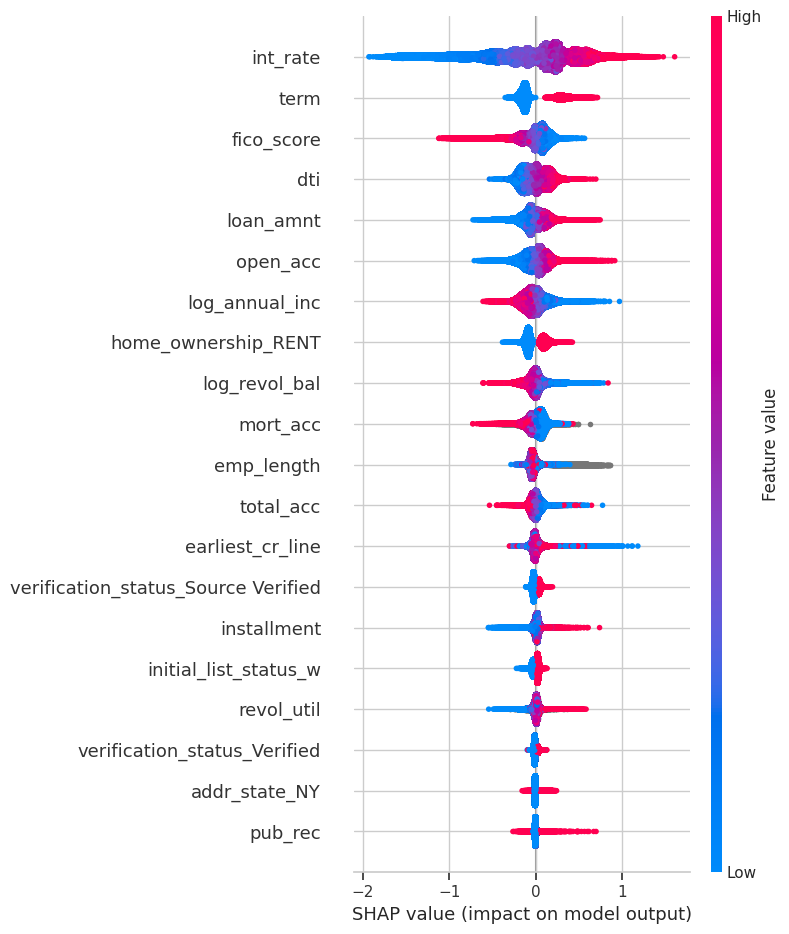

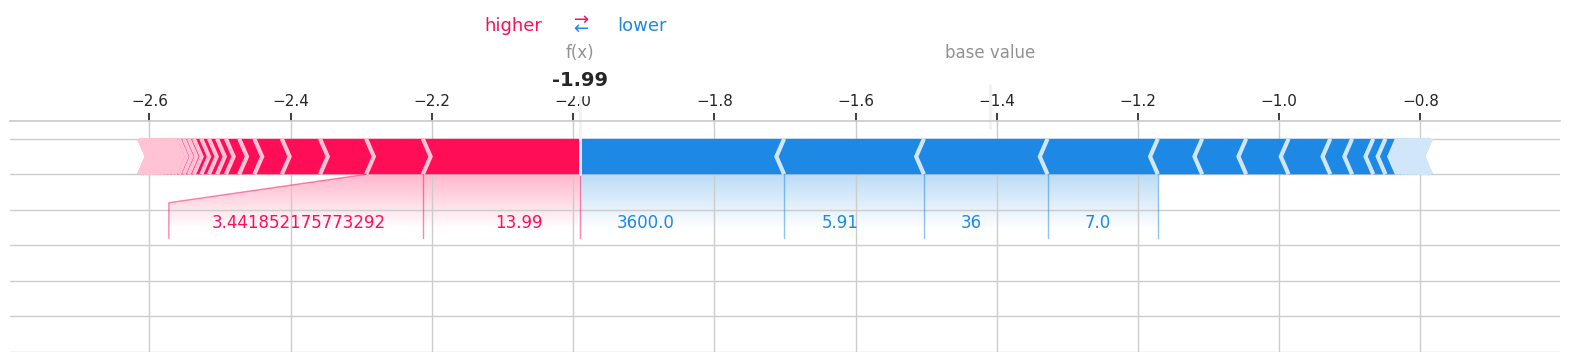

In [217]:
# Explain predictions using TreeExplainer
explainer = shap.TreeExplainer(final_xgb)
shap_values = explainer.shap_values(X_train_val)

# Summary plot (feature importance)
shap.summary_plot(shap_values, X_train_val, feature_names=X_train.columns if hasattr(X_train, 'columns') else None)

# Optional: force plot for first sample
shap.force_plot(explainer.expected_value, shap_values[0,:], X_train_val[0,:], matplotlib=True)

In [221]:
# Pick a sample row
sample_input = X_test.iloc[[42]]  # keep it 2D

# View the feature values
print(sample_input)

# Convert to a dictionary (optional, for easier reading / modification)
sample_dict = sample_input.to_dict(orient='records')[0]
print(sample_dict)
y_pred = final_pipeline_xgb.predict(sample_input)
y_proba = final_pipeline_xgb.predict_proba(sample_input)[:,1]

print("Predicted class:", y_pred[0])
print("Predicted probability:", y_proba[0])

        loan_amnt  term  int_rate  installment  emp_length    dti  \
421338    10000.0    36      7.96       313.18         5.0  29.57   

        earliest_cr_line  open_acc  pub_rec  revol_util  total_acc  mort_acc  \
421338              2006      15.0      1.0        23.5       26.0       2.0   

        pub_rec_bankruptcies  log_annual_inc  fico_score  log_revol_bal  \
421338                   1.0        4.826081       712.0       3.907465   

        sub_grade_A2  sub_grade_A3  sub_grade_A4  sub_grade_A5  sub_grade_B1  \
421338         False         False         False          True         False   

        sub_grade_B2  sub_grade_B3  sub_grade_B4  sub_grade_B5  sub_grade_C1  \
421338         False         False         False         False         False   

        sub_grade_C2  sub_grade_C3  sub_grade_C4  sub_grade_C5  sub_grade_D1  \
421338         False         False         False         False         False   

        sub_grade_D2  sub_grade_D3  sub_grade_D4  sub_grade_D5  su

X has feature names, but SimpleImputer was fitted without feature names
X has feature names, but SimpleImputer was fitted without feature names


In [222]:
import pandas as pd
import shap

# Your sample input dictionary
sample_dict = {
    'loan_amnt': 10000.0, 'term': 36, 'int_rate': 7.96, 'installment': 313.18, 'emp_length': 5.0,
    'dti': 29.57, 'earliest_cr_line': 2006, 'open_acc': 15.0, 'pub_rec': 1.0, 'revol_util': 23.5,
    'total_acc': 26.0, 'mort_acc': 2.0, 'pub_rec_bankruptcies': 1.0, 'log_annual_inc': 4.826081284659646,
    'fico_score': 712.0, 'log_revol_bal': 3.9074651067658563, 'sub_grade_A2': False, 'sub_grade_A3': False,
    'sub_grade_A4': False, 'sub_grade_A5': True, 'sub_grade_B1': False, 'sub_grade_B2': False,
    'sub_grade_B3': False, 'sub_grade_B4': False, 'sub_grade_B5': False, 'sub_grade_C1': False,
    'sub_grade_C2': False, 'sub_grade_C3': False, 'sub_grade_C4': False, 'sub_grade_C5': False,
    'sub_grade_D1': False, 'sub_grade_D2': False, 'sub_grade_D3': False, 'sub_grade_D4': False,
    'sub_grade_D5': False, 'sub_grade_E1': False, 'sub_grade_E2': False, 'sub_grade_E3': False,
    'sub_grade_E4': False, 'sub_grade_E5': False, 'sub_grade_F1': False, 'sub_grade_F2': False,
    'sub_grade_F3': False, 'sub_grade_F4': False, 'sub_grade_F5': False, 'sub_grade_G1': False,
    'sub_grade_G2': False, 'sub_grade_G3': False, 'sub_grade_G4': False, 'sub_grade_G5': False,
    'home_ownership_OTHER': False, 'home_ownership_OWN': False, 'home_ownership_RENT': False,
    'verification_status_Source Verified': True, 'verification_status_Verified': False,
    'purpose_credit_card': False, 'purpose_debt_consolidation': True, 'purpose_educational': False,
    'purpose_home_improvement': False, 'purpose_house': False, 'purpose_major_purchase': False,
    'purpose_medical': False, 'purpose_moving': False, 'purpose_other': False,
    'purpose_renewable_energy': False, 'purpose_small_business': False, 'purpose_vacation': False,
    'purpose_wedding': False, 'addr_state_AL': False, 'addr_state_AR': False, 'addr_state_AZ': False,
    'addr_state_CA': False, 'addr_state_CO': False, 'addr_state_CT': False, 'addr_state_DC': False,
    'addr_state_DE': False, 'addr_state_FL': True, 'addr_state_GA': False, 'addr_state_HI': False,
    'addr_state_IA': False, 'addr_state_ID': False, 'addr_state_IL': False, 'addr_state_IN': False,
    'addr_state_KS': False, 'addr_state_KY': False, 'addr_state_LA': False, 'addr_state_MA': False,
    'addr_state_MD': False, 'addr_state_ME': False, 'addr_state_MI': False, 'addr_state_MN': False,
    'addr_state_MO': False, 'addr_state_MS': False, 'addr_state_MT': False, 'addr_state_NC': False,
    'addr_state_ND': False, 'addr_state_NE': False, 'addr_state_NH': False, 'addr_state_NJ': False,
    'addr_state_NM': False, 'addr_state_NV': False, 'addr_state_NY': False, 'addr_state_OH': False,
    'addr_state_OK': False, 'addr_state_OR': False, 'addr_state_PA': False, 'addr_state_RI': False,
    'addr_state_SC': False, 'addr_state_SD': False, 'addr_state_TN': False, 'addr_state_TX': False,
    'addr_state_UT': False, 'addr_state_VA': False, 'addr_state_VT': False, 'addr_state_WA': False,
    'addr_state_WI': False, 'addr_state_WV': False, 'addr_state_WY': False, 'initial_list_status_w': True,
    'application_type_Joint App': False
}

# Convert to 2D DataFrame
sample_input = pd.DataFrame([sample_dict])

# Predict class and probability
y_pred = final_pipeline_xgb.predict(sample_input)
y_proba = final_pipeline_xgb.predict_proba(sample_input)[:, 1]

print("Predicted class (0/1):", y_pred[0])
print("Predicted probability:", y_proba[0])

# SHAP explanation
explainer = shap.TreeExplainer(final_pipeline_xgb.named_steps['model'])
shap_values = explainer.shap_values(sample_input)

# Visualize
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values, sample_input)

X has feature names, but SimpleImputer was fitted without feature names
X has feature names, but SimpleImputer was fitted without feature names


Predicted class (0/1): 0
Predicted probability: 0.108903416


In [225]:
import pandas as pd
import shap

# -------------------------------
# Full 120-feature sample input (likely charged off)
# -------------------------------
sample_dict = {
    # Numeric features
    'loan_amnt': 15000.0, 'term': 60, 'int_rate': 22.0, 'installment': 450.0, 'emp_length': 1.0,
    'dti': 45.0, 'earliest_cr_line': 2015, 'open_acc': 5.0, 'pub_rec': 2.0, 'revol_util': 90.0,
    'total_acc': 10.0, 'mort_acc': 0.0, 'pub_rec_bankruptcies': 1.0, 'log_annual_inc': 3.5,
    'fico_score': 580.0, 'log_revol_bal': 4.5,

    # Subgrades (A2-G5)
    'sub_grade_A2': False, 'sub_grade_A3': False, 'sub_grade_A4': False, 'sub_grade_A5': False,
    'sub_grade_B1': False, 'sub_grade_B2': False, 'sub_grade_B3': False, 'sub_grade_B4': False, 'sub_grade_B5': True,
    'sub_grade_C1': False, 'sub_grade_C2': False, 'sub_grade_C3': False, 'sub_grade_C4': False, 'sub_grade_C5': False,
    'sub_grade_D1': False, 'sub_grade_D2': False, 'sub_grade_D3': False, 'sub_grade_D4': False, 'sub_grade_D5': False,
    'sub_grade_E1': False, 'sub_grade_E2': False, 'sub_grade_E3': False, 'sub_grade_E4': False, 'sub_grade_E5': False,
    'sub_grade_F1': False, 'sub_grade_F2': False, 'sub_grade_F3': False, 'sub_grade_F4': False, 'sub_grade_F5': False,
    'sub_grade_G1': False, 'sub_grade_G2': False, 'sub_grade_G3': False, 'sub_grade_G4': False, 'sub_grade_G5': False,

    # Home ownership
    'home_ownership_OTHER': False, 'home_ownership_OWN': False, 'home_ownership_RENT': True,

    # Verification
    'verification_status_Source Verified': False, 'verification_status_Verified': True,

    # Purpose
    'purpose_credit_card': False, 'purpose_debt_consolidation': True, 'purpose_educational': False,
    'purpose_home_improvement': False, 'purpose_house': False, 'purpose_major_purchase': False,
    'purpose_medical': False, 'purpose_moving': False, 'purpose_other': False, 'purpose_renewable_energy': False,
    'purpose_small_business': False, 'purpose_vacation': False, 'purpose_wedding': False,

    # States (all 50 states + DC)
    'addr_state_AL': False, 'addr_state_AR': False, 'addr_state_AZ': False, 'addr_state_CA': True, 
    'addr_state_CO': False, 'addr_state_CT': False, 'addr_state_DC': False, 'addr_state_DE': False,
    'addr_state_FL': False, 'addr_state_GA': False, 'addr_state_HI': False, 'addr_state_IA': False, 
    'addr_state_ID': False, 'addr_state_IL': False, 'addr_state_IN': False, 'addr_state_KS': False,
    'addr_state_KY': False, 'addr_state_LA': False, 'addr_state_MA': False, 'addr_state_MD': False,
    'addr_state_ME': False, 'addr_state_MI': False, 'addr_state_MN': False, 'addr_state_MO': False,
    'addr_state_MS': False, 'addr_state_MT': False, 'addr_state_NC': False, 'addr_state_ND': False,
    'addr_state_NE': False, 'addr_state_NH': False, 'addr_state_NJ': False, 'addr_state_NM': False,
    'addr_state_NV': False, 'addr_state_NY': False, 'addr_state_OH': False, 'addr_state_OK': False,
    'addr_state_OR': False, 'addr_state_PA': False, 'addr_state_RI': False, 'addr_state_SC': False,
    'addr_state_SD': False, 'addr_state_TN': False, 'addr_state_TX': False, 'addr_state_UT': False,
    'addr_state_VA': False, 'addr_state_VT': False, 'addr_state_WA': False, 'addr_state_WI': False,
    'addr_state_WV': False, 'addr_state_WY': False,

    # Other categorical
    'initial_list_status_w': True, 'application_type_Joint App': False
}

# -------------------------------
# Convert to 2D DataFrame
# -------------------------------
sample_input = pd.DataFrame([sample_dict])

# -------------------------------
# Predict class and probability
# -------------------------------
y_pred = final_pipeline_xgb.predict(sample_input)
y_proba = final_pipeline_xgb.predict_proba(sample_input)[:, 1]

print("Predicted class (0 = paid, 1 = charged off):", y_pred[0])
print("Predicted probability:", y_proba[0])

# -------------------------------
# SHAP explanation
# -------------------------------
explainer = shap.TreeExplainer(final_pipeline_xgb.named_steps['model'])
shap_values = explainer.shap_values(sample_input)

# Visualize SHAP force plot
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values, sample_input)

X has feature names, but SimpleImputer was fitted without feature names
X has feature names, but SimpleImputer was fitted without feature names


Predicted class (0 = paid, 1 = charged off): 1
Predicted probability: 0.7171561


In [226]:
import joblib

joblib.dump(final_pipeline_xgb, 'xgb_pipeline.pkl')

['xgb_pipeline.pkl']